In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


os.makedirs("cleaned_data", exist_ok=True)
os.makedirs("visuals", exist_ok=True)
os.makedirs("reports", exist_ok=True)

In [2]:
#Load Dataset
healthcare = pd.read_csv(
    "dataset/healthcare_dataset.csv"
)

In [3]:
#Display Data
print("\nFIRST 5 ROWS")
print(healthcare.head())


FIRST 5 ROWS
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18

In [4]:
#Dataset Information
print("\nDATASET INFO")
print(healthcare.info())
print("\nCOLUMN NAMES")
print(healthcare.columns)


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
mem

In [5]:
#Statistical Summary
print("\nSTATISTICAL SUMMARY")
print(healthcare.describe())


STATISTICAL SUMMARY
                Age  Billing Amount   Room Number
count  55500.000000    55500.000000  55500.000000
mean      51.539459    25539.316097    301.134829
std       19.602454    14211.454431    115.243069
min       13.000000    -2008.492140    101.000000
25%       35.000000    13241.224652    202.000000
50%       52.000000    25538.069376    302.000000
75%       68.000000    37820.508436    401.000000
max       89.000000    52764.276736    500.000000


In [6]:
#Check Missing Values
print("\nMISSING VALUES")
print(healthcare.isnull().sum())


MISSING VALUES
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [7]:
#Handle Missing Values
healthcare.fillna(0, inplace=True)

In [8]:
#Remove Duplicates
print("\nDUPLICATES:",
      healthcare.duplicated().sum())

healthcare.drop_duplicates(inplace=True)


DUPLICATES: 534


In [9]:
#Convert Date Columns
date_columns = [
    'Date of Admission',
    'Discharge Date'
]

for col in date_columns:
    if col in healthcare.columns:
        healthcare[col] = pd.to_datetime(
            healthcare[col],
            errors='coerce'
        )

In [10]:
#Feature Engineering
if (
    'Date of Admission' in healthcare.columns and
    'Discharge Date' in healthcare.columns
):

    healthcare['Length_of_Stay'] = (
        healthcare['Discharge Date'] -
        healthcare['Date of Admission']
    ).dt.days

In [11]:
#Label Encoding
label_encoder = LabelEncoder()

for column in healthcare.columns:
    if healthcare[column].dtype == 'object':
        healthcare[column] = label_encoder.fit_transform(
            healthcare[column].astype(str)
        )

In [12]:
#Save Cleaned Data
healthcare.to_csv(
    "cleaned_data/cleaned_healthcare_data.csv",
    index=False
)

print("\nCLEANED DATA SAVED SUCCESSFULLY")


CLEANED DATA SAVED SUCCESSFULLY


In [13]:
#Basic Analysis
print("\nDATASET SHAPE")
print(healthcare.shape)


DATASET SHAPE
(54966, 16)


In [14]:
#Correlation Matrix
correlation = healthcare.corr(numeric_only=True)

print("\nCORRELATION MATRIX")
print(correlation)


CORRELATION MATRIX
                        Name       Age    Gender  Blood Type  \
Name                1.000000  0.001151  0.007992   -0.001075   
Age                 0.001151  1.000000 -0.002510   -0.000031   
Gender              0.007992 -0.002510  1.000000   -0.000690   
Blood Type         -0.001075 -0.000031 -0.000690    1.000000   
Medical Condition   0.003250 -0.002800  0.000746   -0.004183   
Doctor             -0.005099 -0.003225 -0.002916   -0.004764   
Hospital            0.003629  0.001728  0.003262   -0.000457   
Insurance Provider -0.001197 -0.005222 -0.003267   -0.001097   
Billing Amount     -0.001584 -0.003427  0.004939   -0.000575   
Room Number        -0.001004 -0.000352 -0.006764    0.004465   
Admission Type      0.004086  0.004098  0.009642   -0.004305   
Medication          0.000286 -0.006073  0.007855    0.002778   
Test Results        0.005377 -0.006974  0.005073   -0.000717   
Length_of_Stay      0.001011  0.007890  0.004224   -0.001702   

                   

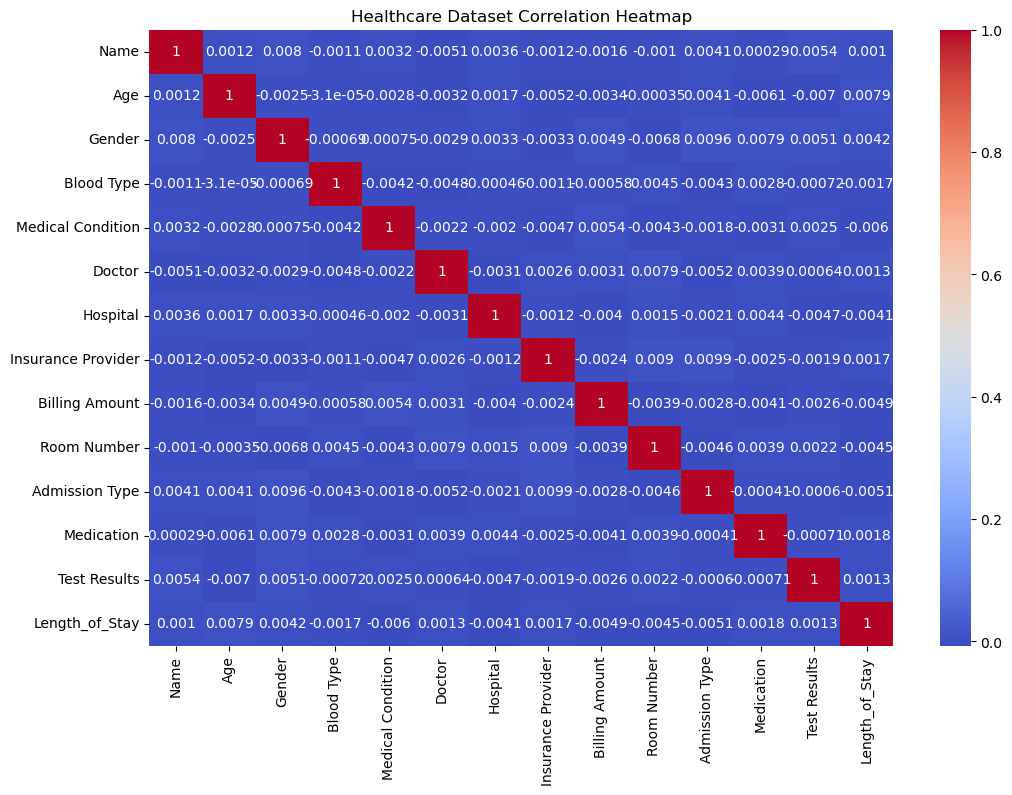

In [15]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Healthcare Dataset Correlation Heatmap")

plt.savefig(
    "visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

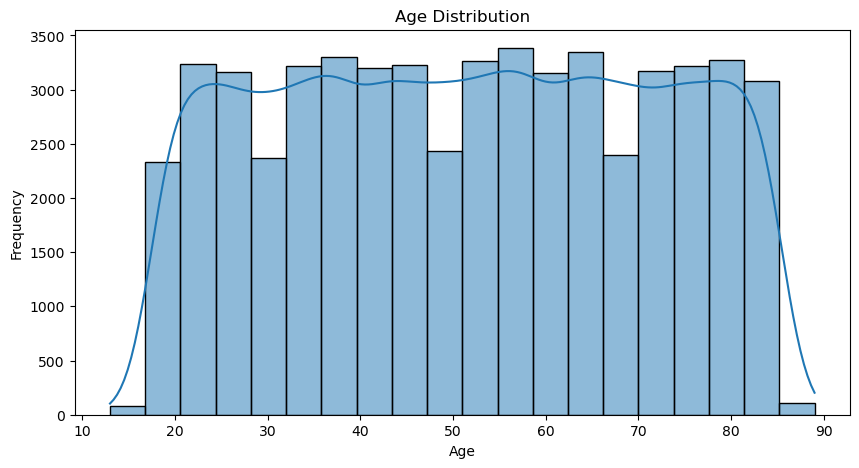

In [16]:
#Age Distribution
if 'Age' in healthcare.columns:
    plt.figure(figsize=(10,5))

    sns.histplot(
        healthcare['Age'],
        bins=20,
        kde=True
    )

    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")

    plt.savefig(
        "visuals/age_distribution.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

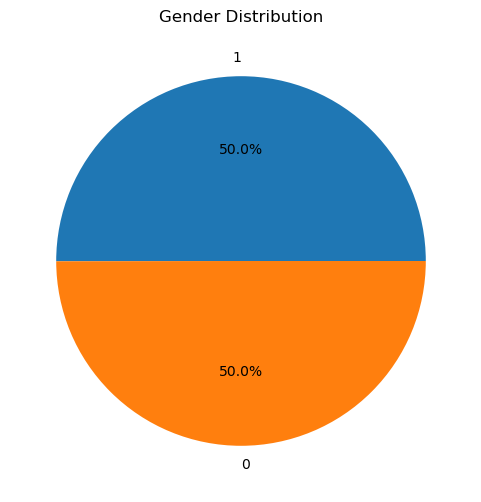

In [17]:
#Gender Distribution
if 'Gender' in healthcare.columns:
    plt.figure(figsize=(6,6))

    healthcare['Gender'].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )

    plt.title("Gender Distribution")

    plt.ylabel("")

    plt.savefig(
        "visuals/gender_distribution.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

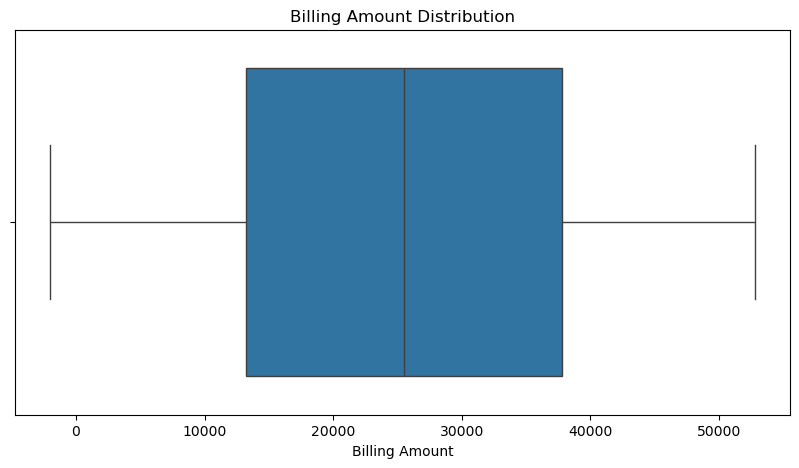

In [18]:
#Billing Amount Distribution
if 'Billing Amount' in healthcare.columns:
    plt.figure(figsize=(10,5))

    sns.boxplot(
        x=healthcare['Billing Amount']
    )

    plt.title("Billing Amount Distribution")

    plt.savefig(
        "visuals/billing_boxplot.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

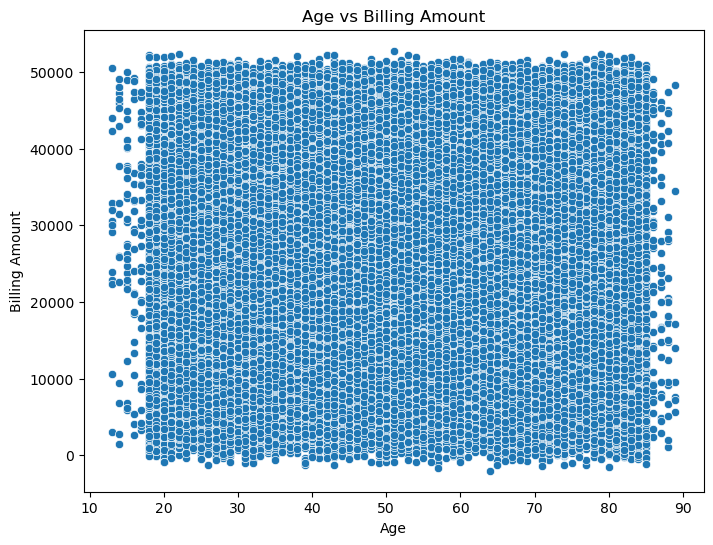

In [19]:
#Scatter Plot
if (
    'Age' in healthcare.columns and
    'Billing Amount' in healthcare.columns
):

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        x='Age',
        y='Billing Amount',
        data=healthcare
    )

    plt.title("Age vs Billing Amount")

    plt.savefig(
        "visuals/age_vs_billing.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


TRAINING DATA: (43972, 13)
TESTING DATA: (10994, 13)

LINEAR REGRESSION R2 SCORE: 3.871263623667076e-05

DECISION TREE R2 SCORE: -0.7942058079408876

RANDOM FOREST R2 SCORE: 0.09328788329620774

MODEL COMPARISON
               Model  R2 Score
0  Linear Regression  0.000039
1      Decision Tree -0.794206
2      Random Forest  0.093288


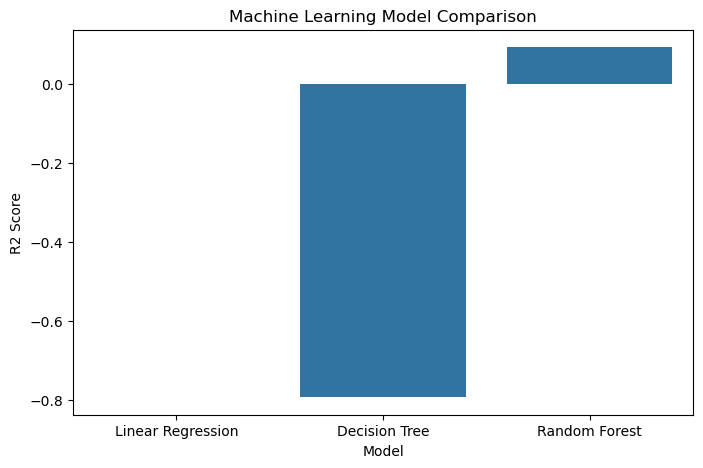

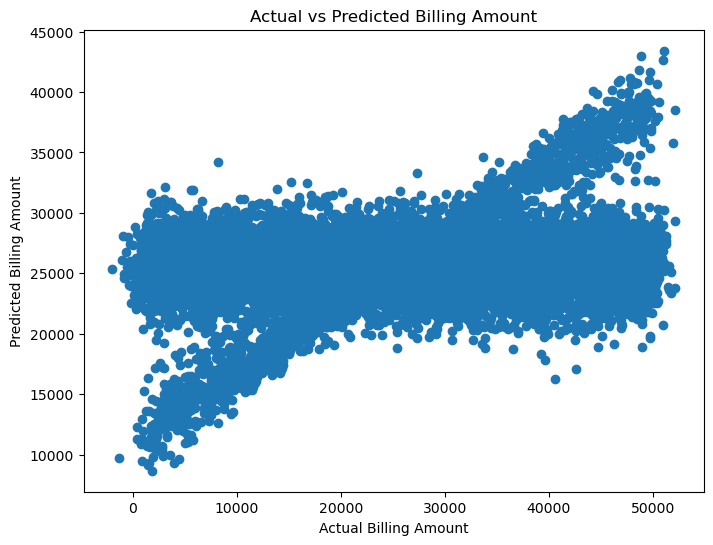

In [20]:
#Machine Learning Prediction
if 'Billing Amount' in healthcare.columns:
    # Remove rows with missing target
    healthcare = healthcare.dropna(
        subset=['Billing Amount']
    )

    # Features
    X = healthcare.drop(
        columns=['Billing Amount']
    )

    # Keep only numeric columns
    X = X.select_dtypes(
        include=[np.number]
    )

    # Target
    y = healthcare['Billing Amount']

    # Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print("\nTRAINING DATA:", X_train.shape)
    print("TESTING DATA:", X_test.shape)

    # Linear Regression
    linear_model = LinearRegression()
    linear_model.fit(
        X_train,
        y_train
    )
    linear_predictions = linear_model.predict(
        X_test
    )
    linear_r2 = r2_score(
        y_test,
        linear_predictions
    )
    print("\nLINEAR REGRESSION R2 SCORE:",
          linear_r2)

    # Decision Tree
    tree_model = DecisionTreeRegressor(
        random_state=42
    )
    tree_model.fit(
        X_train,
        y_train
    )
    tree_predictions = tree_model.predict(
        X_test
    )
    tree_r2 = r2_score(
        y_test,
        tree_predictions
    )
    print("\nDECISION TREE R2 SCORE:",
          tree_r2)

    # Random Forest
    forest_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    forest_model.fit(
        X_train,
        y_train
    )
    forest_predictions = forest_model.predict(
        X_test
    )
    forest_r2 = r2_score(
        y_test,
        forest_predictions
    )
    print("\nRANDOM FOREST R2 SCORE:",
          forest_r2)

  # Model Comparison Table
    results = pd.DataFrame({

        'Model': [
            'Linear Regression',
            'Decision Tree',
            'Random Forest'
        ],

        'R2 Score': [
            linear_r2,
            tree_r2,
            forest_r2
        ]
    })

    print("\nMODEL COMPARISON")
    print(results)

    # Save Results
    results.to_csv(
        "reports/model_comparison.csv",
        index=False
    )

    # Model Comparison
    plt.figure(figsize=(8,5))

    sns.barplot(
        x='Model',
        y='R2 Score',
        data=results
    )

    plt.title("Machine Learning Model Comparison")

    plt.savefig(
        "visuals/model_comparison.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    # Actual VS Predicted
    plt.figure(figsize=(8,6))

    plt.scatter(
        y_test,
        forest_predictions
    )

    plt.xlabel("Actual Billing Amount")
    plt.ylabel("Predicted Billing Amount")
    plt.title("Actual vs Predicted Billing Amount")

    plt.savefig(
        "visuals/actual_vs_predicted.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [21]:
#Generate Final Report
report = f"""
HEALTHCARE REAL-WORLD DATA ANALYSIS REPORT
==========================================

PROJECT OBJECTIVE
-----------------
Perform healthcare data analysis and
machine learning prediction using
real-world healthcare datasets.

DATA CLEANING PERFORMED
-----------------------
- Handled missing values
- Removed duplicates
- Converted date columns
- Performed label encoding
- Feature engineering

ANALYSIS PERFORMED
------------------
- Statistical summaries
- Correlation analysis
- Distribution analysis
- Billing analysis
- Machine learning prediction

MACHINE LEARNING MODELS USED
----------------------------
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

KEY INSIGHTS
-------------
- Patient billing trends analyzed
- Age distributions identified
- Correlations between healthcare factors observed
- Machine learning models compared

TECHNOLOGIES USED
-----------------
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

PROJECT OUTCOME
---------------
Applied data science skills in a
real-world healthcare domain using
data analysis, visualization, and
machine learning techniques.
"""

with open(
    "reports/final_healthcare_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("\nREPORT GENERATED SUCCESSFULLY")


REPORT GENERATED SUCCESSFULLY
